In [3]:
import pandas as pd

df = pd.read_csv("../data/Instagram_Reels_Data_Cleaned.csv")

df.head()

,Unnamed: 0,hashtags,lemmatized_tags,number_of_tags,topic,encoded_topic
0,0,reels fyp barcelona realmadrid,reel fyp barcelona realmadrid,4,Sports,21
1,1,reelsindia reelsvideos instareels instagramree...,reelsindia reelsvideo instareels instagramreel...,7,Relationships,18
2,2,reels comedy kannadareels yashwanthshetty kann...,reel comedy kannadareel yashwanthshetty kannad...,6,Comedy,4
3,3,pokemon pokemongo nostalgia retrogaming,pokemon pokemongo nostalgia retrogame,4,Gaming,12
4,4,vibes trending milkshake,vibe trend milkshake,3,Food,11


In [4]:
df.columns

Index(['Unnamed: 0', 'hashtags', 'lemmatized_tags', 'number_of_tags', 'topic',
       'encoded_topic'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       3263 non-null   int64 
 1   hashtags         3036 non-null   object
 2   lemmatized_tags  3036 non-null   object
 3   number_of_tags   3263 non-null   int64 
 4   topic            3263 non-null   object
 5   encoded_topic    3263 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 153.1+ KB


In [6]:
df.isnull().sum()

Unnamed: 0           0
hashtags           227
lemmatized_tags    227
number_of_tags       0
topic                0
encoded_topic        0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

df.fillna("", inplace=True)

In [9]:
df.head()

,Unnamed: 0,hashtags,lemmatized_tags,number_of_tags,topic,encoded_topic
0,0,reels fyp barcelona realmadrid,reel fyp barcelona realmadrid,4,Sports,21
1,1,reelsindia reelsvideos instareels instagramree...,reelsindia reelsvideo instareels instagramreel...,7,Relationships,18
2,2,reels comedy kannadareels yashwanthshetty kann...,reel comedy kannadareel yashwanthshetty kannad...,6,Comedy,4
3,3,pokemon pokemongo nostalgia retrogaming,pokemon pokemongo nostalgia retrogame,4,Gaming,12
4,4,vibes trending milkshake,vibe trend milkshake,3,Food,11


In [6]:
from collections import Counter
import pandas as pd

all_tags = " ".join(
    df['lemmatized_tags'].astype(str)
)

words = all_tags.split()

common_tags = Counter(words)

top_tags = pd.DataFrame(
    common_tags.most_common(10),
    columns=['hashtag', 'count']
)

print(top_tags)

          hashtag  count
0             nan    227
1            reel    199
2           trend    196
3         explore    154
4           viral    143
5       instagram    129
6            meme    123
7     explorepage    122
8  reelsinstagram    116
9             fyp    114


In [7]:
top_tags.to_csv(
    "../data/top_hashtags.csv",
    index=False
)

In [11]:
df.columns

Index(['Unnamed: 0', 'hashtags', 'lemmatized_tags', 'number_of_tags', 'topic',
       'encoded_topic'],
      dtype='object')

In [12]:
df.shape

(3263, 6)

In [13]:
df['topic'].value_counts()

topic
Fitness          232
Education        230
Society          209
Trends           190
Comedy           186
Cinema           172
Sports           160
Technology       154
Motivation       149
Relationships    138
Spirituality     137
Travel           127
Music            126
Animals          120
Food             108
Fashion          101
Knowledge         92
Photography       90
Architecture      83
Wildlife          80
Healthcare        80
Crafts            78
Dance             65
Business          62
Gaming            52
Festivals         42
Name: count, dtype: int64

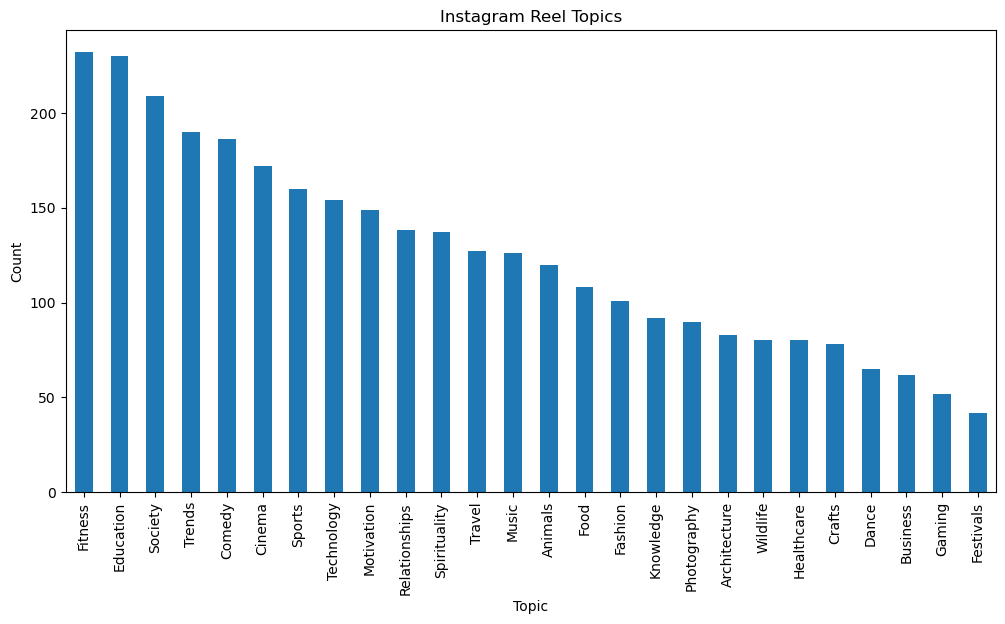

In [14]:
import matplotlib.pyplot as plt

df['topic'].value_counts().plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Instagram Reel Topics")
plt.xlabel("Topic")
plt.ylabel("Count")

plt.show()

In [15]:
df['number_of_tags'].describe()

count    3263.000000
mean        7.541833
std         6.470611
min         0.000000
25%         3.000000
50%         6.000000
75%        10.000000
max        40.000000
Name: number_of_tags, dtype: float64

In [16]:
df.groupby('topic')['number_of_tags'].mean()

topic
Animals          12.216667
Architecture      3.807229
Business          4.758065
Cinema           10.418605
Comedy            8.983871
Crafts            6.205128
Dance             5.861538
Education         7.982609
Fashion           5.267327
Festivals         5.595238
Fitness           6.181034
Food              7.620370
Gaming            7.423077
Healthcare        6.550000
Knowledge         2.282609
Motivation        7.550336
Music             9.198413
Photography       5.044444
Relationships     6.413043
Society           8.215311
Spirituality      8.715328
Sports            9.043750
Technology        8.077922
Travel            6.944882
Trends            8.721053
Wildlife          5.750000
Name: number_of_tags, dtype: float64

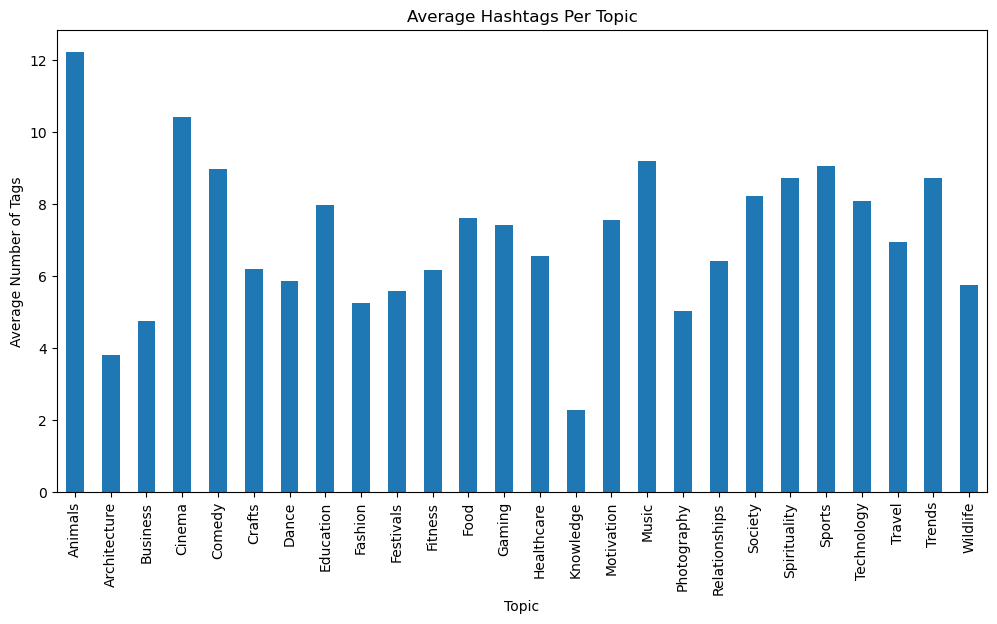

In [17]:
df.groupby('topic')['number_of_tags'].mean().plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Average Hashtags Per Topic")
plt.xlabel("Topic")
plt.ylabel("Average Number of Tags")

plt.show()

In [18]:
all_tags = " ".join(df['lemmatized_tags'].astype(str))

words = all_tags.split()

from collections import Counter

common_tags = Counter(words)

common_tags.most_common(20)

[('reel', 199),
 ('trend', 196),
 ('explore', 154),
 ('viral', 143),
 ('instagram', 129),
 ('meme', 123),
 ('explorepage', 122),
 ('reelsinstagram', 116),
 ('fyp', 114),
 ('trendingreel', 109),
 ('online', 103),
 ('funny', 97),
 ('youtube', 84),
 ('comedy', 83),
 ('unk', 77),
 ('love', 75),
 ('instagood', 75),
 ('india', 69),
 ('website', 67),
 ('video', 66)]

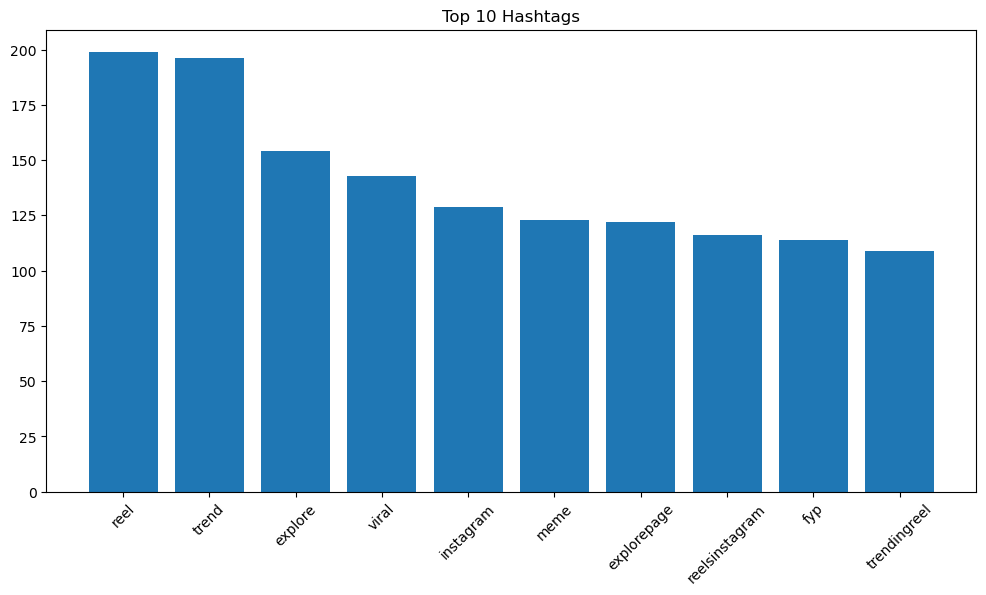

In [19]:
tags = dict(common_tags.most_common(10))

plt.figure(figsize=(12,6))

plt.bar(tags.keys(), tags.values())

plt.xticks(rotation=45)

plt.title("Top 10 Hashtags")

plt.show()

In [2]:
!pip install wordcloud

  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl (306 kB)


In [2]:
import pandas as pd

df = pd.read_csv("../data/Instagram_Reels_Data_Cleaned.csv")

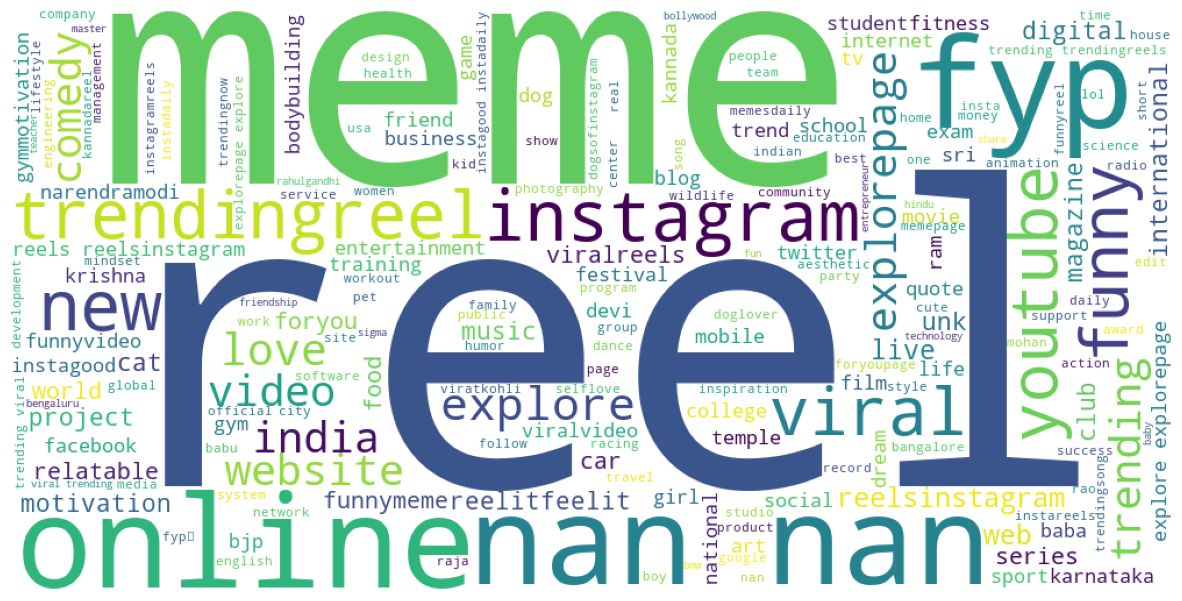

In [3]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['hashtags'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [4]:
df.to_csv(
    "../data/cleaned_reels_analysis.csv",
    index=False
)

In [5]:
df.to_csv(
    "../data/cleaned_reels_analysis.csv",
    index=False
)

In [8]:
df['hashtags'].isna().sum()

np.int64(227)

In [9]:
df_clean = df.dropna(subset=['hashtags'])

In [10]:
df_clean['hashtags'].isna().sum()

np.int64(0)

In [11]:
top_tags.head(20)

,hashtag,count
0,nan,227
1,reel,199
2,trend,196
3,explore,154
4,viral,143
5,instagram,129
6,meme,123
7,explorepage,122
8,reelsinstagram,116
9,fyp,114


In [12]:
top_tags = top_tags[top_tags['hashtag'] != 'nan']

In [13]:
top_tags.to_csv(
    "../data/top_hashtags.csv",
    index=False
)

In [14]:
top_tags.head(20)

,hashtag,count
1,reel,199
2,trend,196
3,explore,154
4,viral,143
5,instagram,129
6,meme,123
7,explorepage,122
8,reelsinstagram,116
9,fyp,114


In [15]:
top_tags.to_csv("../data/top_hashtags.csv", index=False)